In [8]:
import pandas as pd
import numpy as np

data = pd.read_csv("sp500_raw.csv")

data["MA10"] = data["Close"].rolling(window=10).mean()
data["MA50"] = data["Close"].rolling(window=50).mean()

delta = data["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

data["Return"] = data["Close"].pct_change()

data = data.dropna().reset_index(drop=True)

print(data.shape)
data.head()

(1205, 10)


,Date,Close,High,Low,Open,Volume,MA10,MA50,RSI,Return
0,2021-11-11,4649.270020,4664.549805,4648.310059,4659.390137,3926870000,4657.078955,4489.451563,70.027246,0.000551
1,2021-11-12,4682.850098,4688.470215,4650.770020,4655.240234,3728600000,4664.825977,4492.369561,71.346807,0.007223
2,2021-11-15,4682.799805,4697.419922,4672.859863,4689.299805,3488410000,4671.738965,4495.316953,70.432360,-0.000011
3,2021-11-16,4700.899902,4714.950195,4679.419922,4679.419922,3972640000,4678.763965,4498.934355,78.773482,0.003865
4,2021-11-17,4688.669922,4701.500000,4684.410156,4701.500000,3969070000,4681.573975,4502.426357,70.338107,-0.002602


In [9]:
from sklearn.preprocessing import MinMaxScaler

features = ["Close", "High", "Low", "Open", "Volume", "MA10", "MA50", "RSI", "Return"]

scaler2 = MinMaxScaler()
scaled_data2 = scaler2.fit_transform(data[features])

WINDOW_SIZE = 60
return_index = features.index("Return")

X2 = []
y2 = []

for i in range(WINDOW_SIZE, len(scaled_data2)):
    X2.append(scaled_data2[i-WINDOW_SIZE:i])
    y2.append(scaled_data2[i, return_index])

X2 = np.array(X2)
y2 = np.array(y2)

print(X2.shape, y2.shape)

(1145, 60, 9) (1145,)


In [10]:
split_index2 = int(len(X2) * 0.8)

X2_train, X2_test = X2[:split_index2], X2[split_index2:]
y2_train, y2_test = y2[:split_index2], y2[split_index2:]

print(X2_train.shape, X2_test.shape)

(916, 60, 9) (229, 60, 9)


In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model2 = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(X2_train.shape[1], X2_train.shape[2])),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model2.compile(optimizer="adam", loss="mean_squared_error")
model2.summary()

c:\Users\scghl\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history2 = model2.fit(
    X2_train, y2_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0170 - val_loss: 0.0020
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0016
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0061 - val_loss: 0.0015
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0015
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0021
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0064 - val_loss: 0.0017
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0062 - val_loss: 0.0015
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0061 - val_loss: 0.0017
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0020
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0063 - val_loss: 0.0020
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

In [13]:
predictions2_scaled = model2.predict(X2_test)

return_index = 8  # Return was the last column in our features list

dummy2 = np.zeros((len(predictions2_scaled), 9))
dummy2[:, return_index] = predictions2_scaled[:, 0]
predicted_returns = scaler2.inverse_transform(dummy2)[:, return_index]

dummy2_actual = np.zeros((len(y2_test), 9))
dummy2_actual[:, return_index] = y2_test
actual_returns = scaler2.inverse_transform(dummy2_actual)[:, return_index]

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae2 = mean_absolute_error(actual_returns, predicted_returns)
rmse2 = np.sqrt(mean_squared_error(actual_returns, predicted_returns))

print(f"Return MAE: {mae2:.5f}")
print(f"Return RMSE: {rmse2:.5f}")

predicted_direction2 = np.where(predicted_returns > 0, 1, 0)
actual_direction2 = np.where(actual_returns > 0, 1, 0)

accuracy2 = (predicted_direction2 == actual_direction2).mean()
print(f"Directional Accuracy: {accuracy2*100:.2f}%")

print(f"\nPredicted returns - min: {predicted_returns.min():.5f}, max: {predicted_returns.max():.5f}, std: {predicted_returns.std():.5f}")
print(f"Actual returns    - min: {actual_returns.min():.5f}, max: {actual_returns.max():.5f}, std: {actual_returns.std():.5f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Return MAE: 0.00650
Return RMSE: 0.00850
Directional Accuracy: 46.29%

Predicted returns - min: -0.00279, max: 0.00032, std: 0.00066
Actual returns    - min: -0.02711, max: 0.02913, std: 0.00832


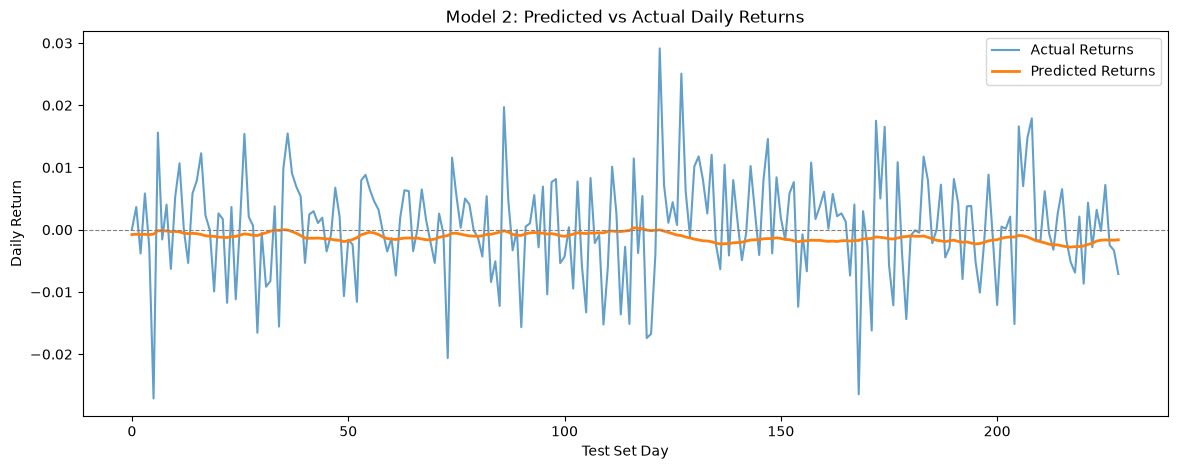

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(actual_returns, label="Actual Returns", alpha=0.7)
plt.plot(predicted_returns, label="Predicted Returns", linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Model 2: Predicted vs Actual Daily Returns")
plt.xlabel("Test Set Day")
plt.ylabel("Daily Return")
plt.legend()
plt.savefig("returns_predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()